# Make MMH dataset - Supply & Demand
# 1. install required packages

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import random
import torch
import pickle

# 2. import raw demand dataset

In [ ]:
%%time
path = 'MMH_dataset'

seoul_pop_grid = gpd.read_file(path + '/demand_pop.shp')
seoul_pop_grid['POINT_X'] = seoul_pop_grid.geometry.x
seoul_pop_grid['POINT_Y'] = seoul_pop_grid.geometry.y

seoul_pop_grid = seoul_pop_grid.loc[:, ['Field2', 'Field4', 'geometry', 'POINT_X', 'POINT_Y']]
seoul_pop_grid.columns = ['id', 'value','geometry', 'POINT_X', 'POINT_Y']

n_points = len(seoul_pop_grid)
total_pop = int(sum(seoul_pop_grid['value']))
print("The number of records is ", n_points)
print("The total population is ", total_pop)

The number of records is  2152
The total population is  9622840
Wall time: 166 ms


# 3. import raw supply dataset

In [38]:
seoul_med_shp = gpd.read_file(path +'/supply_point.shp')
seoul_med_shp.dropna(subset=['geometry'], inplace = True)
seoul_med_shp.reset_index(drop = False, inplace=True)
seoul_med_shp = (seoul_med_shp
                .loc[:, ['index', 'geometry']]
                .rename(columns={'index': 'FID'}))
seoul_med_shp.head()

,FID,geometry
0,0,POINT (950223.691 1961384.548)
1,1,POINT (948696.366 1958572.497)
2,2,POINT (948702.424 1958581.553)
3,3,POINT (948814.384 1959244.768)
4,4,POINT (948845.496 1959283.538)


In [39]:
seoul_med_shp['POINT_X'] = seoul_med_shp.geometry.x
seoul_med_shp['POINT_Y'] = seoul_med_shp.geometry.y

# 4. raw data visualization 

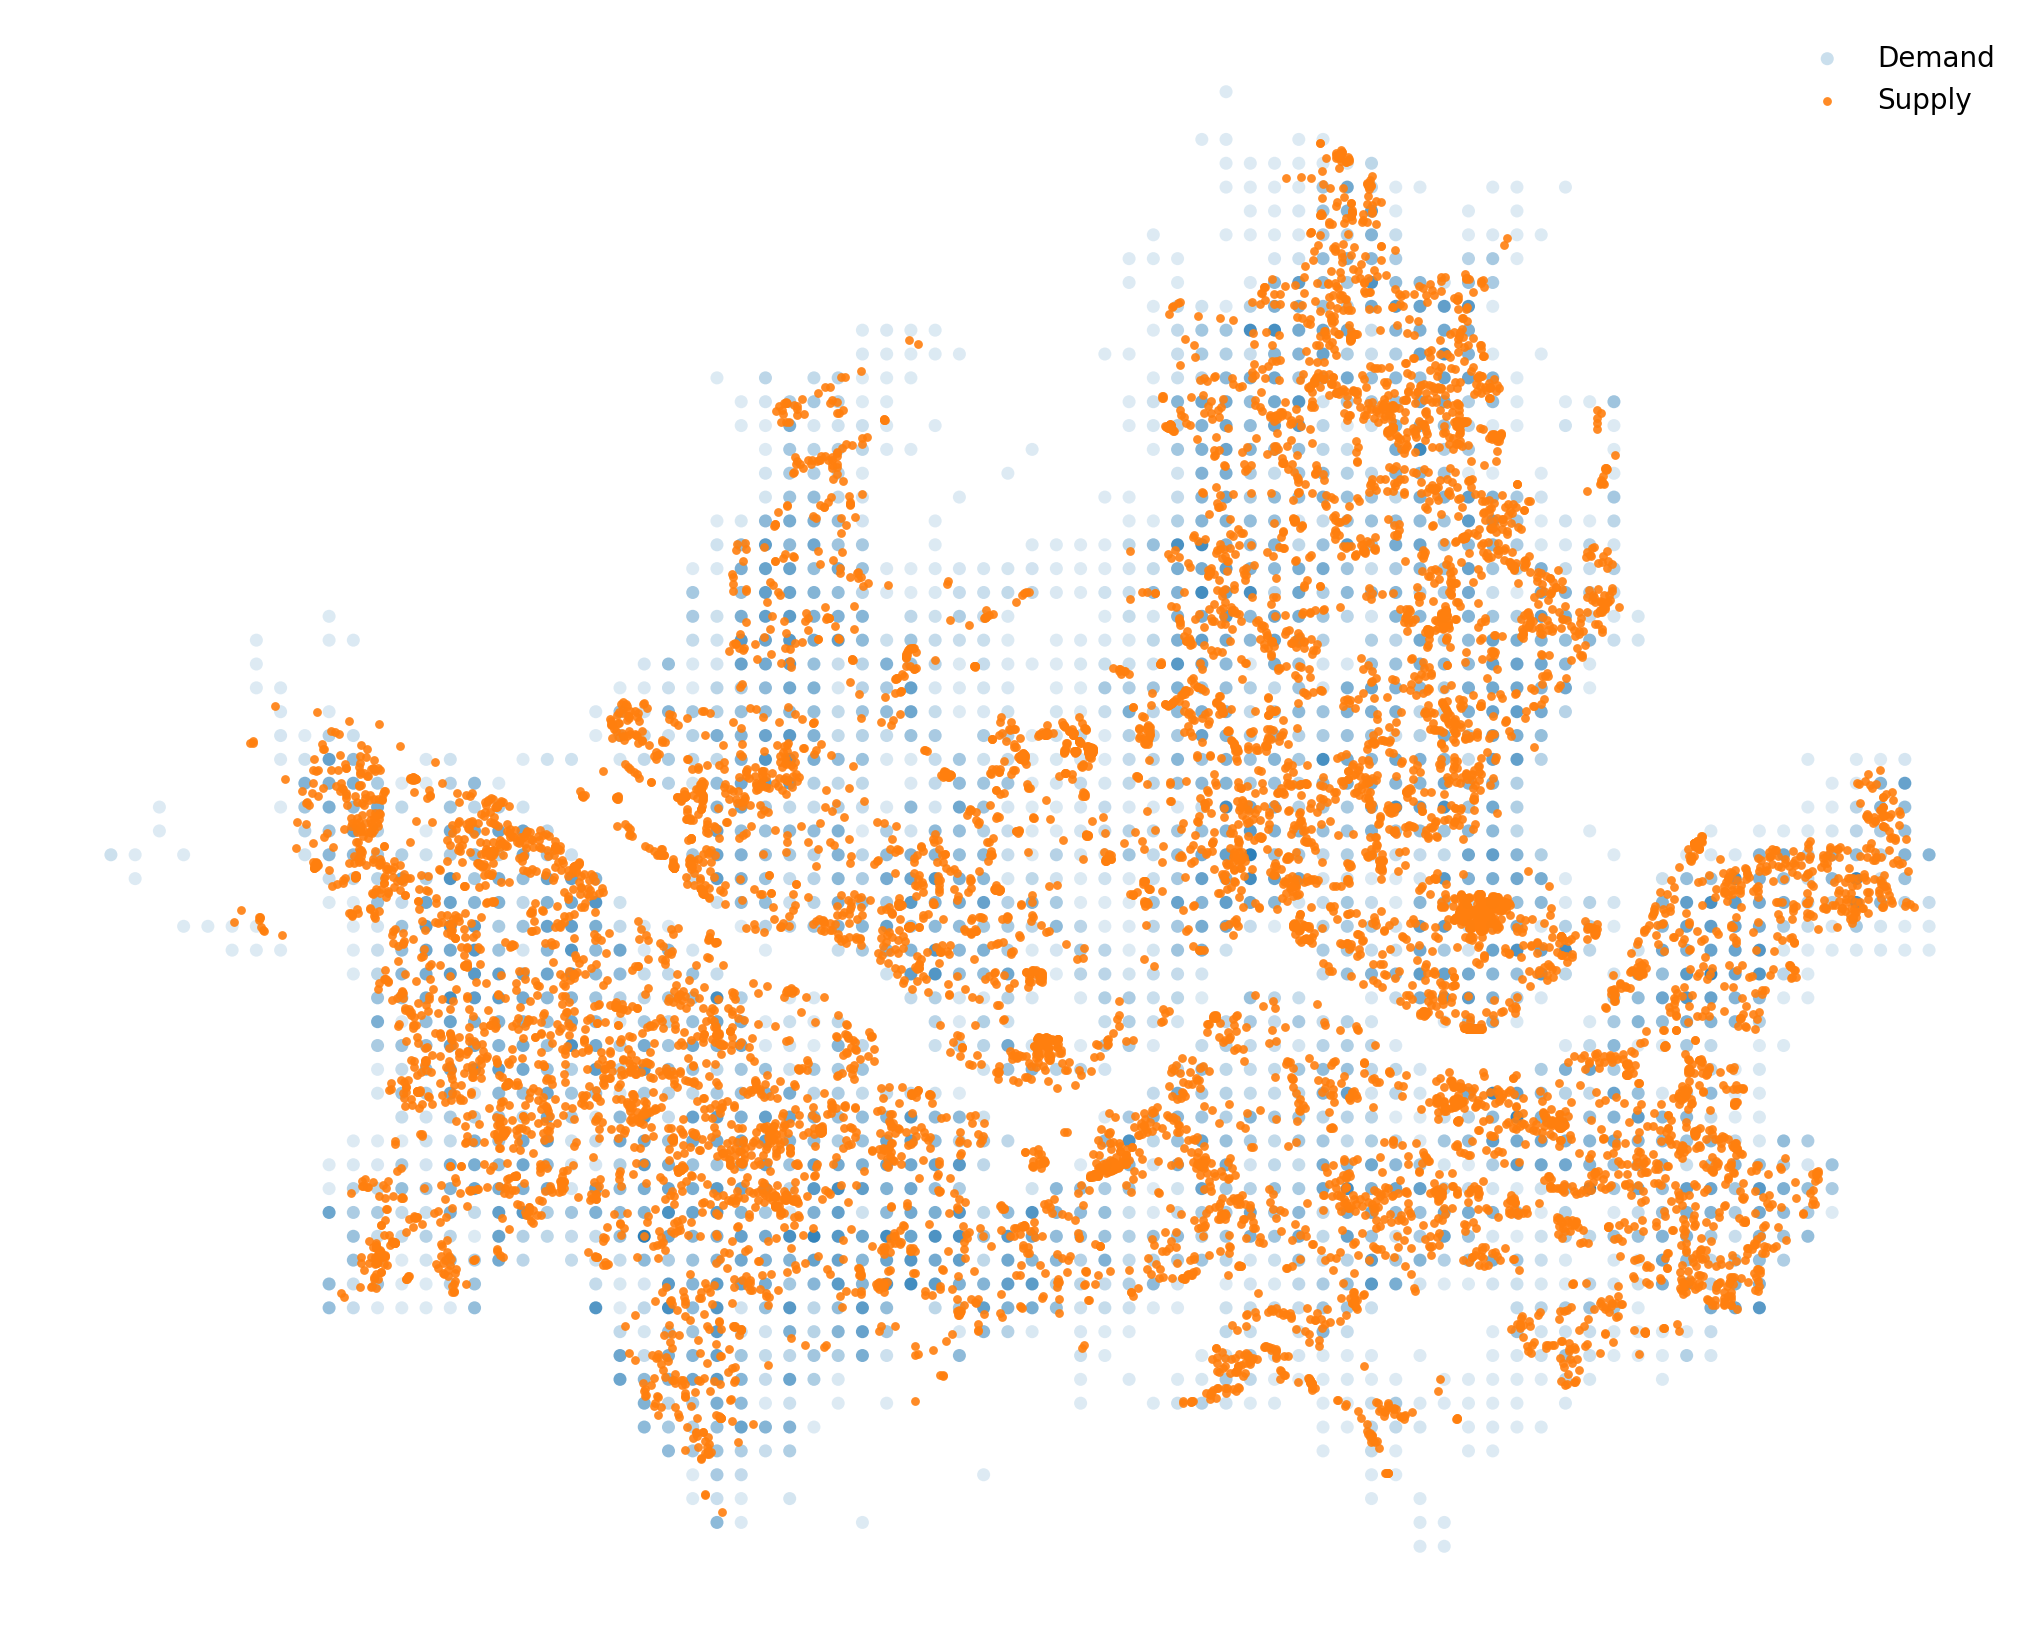

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# ---- Demand (alpha by value) ----
v = seoul_pop_grid["value"].astype(float).fillna(0).to_numpy()
vmax = np.nanmax(v) if np.nanmax(v) > 0 else 1.0
vn = np.clip(v / vmax, 0, 1)  # 0~1 정규화

# alpha 범위(최소/최대) 설정
alpha_min, alpha_max = 0.15, 0.95
alphas = alpha_min + vn * (alpha_max - alpha_min)

x_d = seoul_pop_grid.geometry.x.to_numpy()
y_d = seoul_pop_grid.geometry.y.to_numpy()

ax.scatter(x_d, y_d, s=22, alpha=alphas, linewidths=0, label="Demand")

# ---- Supply (고정 alpha) ----
x_s = seoul_med_shp.geometry.x.to_numpy()
y_s = seoul_med_shp.geometry.y.to_numpy()
ax.scatter(x_s, y_s, s=10, alpha=0.9, linewidths=0, label="Supply")

# ---- Clean figure ----
ax.set_axis_off()
ax.legend(frameon=False, loc="upper right")
plt.tight_layout(pad=0)
plt.show()

# 5. make train dataset

- total train dataset: 128000

- demand point location & attribute: `seoul_pop_grid`

- candidate facilities: select 100 randomly sampled items

- service range: 2000m

- number of facilities to be finalized: 20

In [ ]:
def Normalization(x, y):
    max_x, max_y = np.max(x), np.max(y)
    min_x, min_y = np.min(x), np.min(y)
    S_x = (max_x-min_x)
    S_y = (max_y-min_y)
    S = max(S_x, S_y)
    new_x, new_y = (x-min_x)/S, (y-min_y)/S
    data_xy = np.vstack((new_x, new_y))
    Data = data_xy.T
    return new_x, new_y, S
    
def normalize_to_1_10(data):
    min_val = min(data)
    max_val = max(data)
    normalized_data = [(x - min_val) / (max_val - min_val) * 9 + 1 for x in data]
    return normalized_data

def generate_candidate_sites(sites, M=100, heuristic=None):
    '''
    Generate M candidate sites with the convex hull of a point set
    Input:
        sites: a Pandas DataFrame with X, Y and other characteristic
        M: the number of candidate sites to generate
        heuristic:
    Return:
        sites: a Numpy array with shape of (M,2)
    '''
    if M is not None:
        if M > len(sites):
            M = None
    if heuristic is None or heuristic == '':
        if M is None:
            return sites
        index = np.random.choice(len(sites), M)
        return sites.iloc[index]
    elif heuristic == 'coverage':
        sites = sites.sort_values(by='pop_covered_2km', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]
    elif heuristic == 'coverage_e':
        sites = sites.sort_values(by='pop_covered_2km_exclusive', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]
    elif heuristic == 'impression':
        sites = sites.sort_values(by='weeklyImpr', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]
    elif heuristic == 'impression_e':
        sites = sites.sort_values(by='weeklyImpr_2km_exclusive', ascending=False).reset_index()
        if M is None:
            return sites
        return sites.iloc[:M]

In [ ]:
seoul_pop_grid['val_norm'] = normalize_to_1_10(seoul_pop_grid['value']) 
seoul_pop_grid_X = np.array(seoul_pop_grid['POINT_X'])
seoul_pop_grid_Y = np.array(seoul_pop_grid['POINT_Y'])
seoul_meds_X = np.array(seoul_med_shp['POINT_X'])
seoul_meds_Y = np.array(seoul_med_shp['POINT_Y'])
X = np.concatenate([seoul_pop_grid_X, seoul_meds_X])
Y = np.concatenate([seoul_pop_grid_Y, seoul_meds_Y])
NORM_X, NORM_Y, S = Normalization(X, Y)
seoul_pop_grid['NORM_X'] = NORM_X[:len(seoul_pop_grid)]
seoul_pop_grid['NORM_Y'] = NORM_Y[:len(seoul_pop_grid)]
seoul_med_shp['NORM_X'] = NORM_X[len(seoul_pop_grid):]
seoul_med_shp['NORM_Y'] = NORM_Y[len(seoul_pop_grid):]

In [51]:
seoul_pop_grid.head()

,id,value,geometry,POINT_X,POINT_Y,val_norm,NORM_X,NORM_Y
0,다사60b41b,1514,POINT (960750.000 1941750.000),960750.0,1941750.0,1.947303,0.693333,0.133333
1,다사55a42b,7394,POINT (955250.000 1942750.000),955250.0,1942750.0,5.626390,0.546667,0.160000
2,다사44a47b,8786,POINT (944250.000 1947750.000),944250.0,1947750.0,6.497358,0.253333,0.293333
3,다사66b45a,6528,POINT (966750.000 1945250.000),966750.0,1945250.0,5.084538,0.853333,0.226667
4,다사48b56a,10308,POINT (948750.000 1956250.000),948750.0,1956250.0,7.449666,0.373333,0.520000


In [52]:
seoul_med_shp.head()

,FID,geometry,POINT_X,POINT_Y,NORM_X,NORM_Y
0,0,POINT (950223.691 1961384.548),950223.691302,1.961385e+06,0.412632,0.656921
1,1,POINT (948696.366 1958572.497),948696.365809,1.958572e+06,0.371903,0.581933
2,2,POINT (948702.424 1958581.553),948702.423993,1.958582e+06,0.372065,0.582175
3,3,POINT (948814.384 1959244.768),948814.384284,1.959245e+06,0.375050,0.599860
4,4,POINT (948845.496 1959283.538),948845.496235,1.959284e+06,0.375880,0.600894


In [53]:
def gen_train_data_original(num_sample):
    train_datasets = []
    users_data = torch.tensor(np.array(seoul_pop_grid[['NORM_X', 'NORM_Y']])).to(torch.float32)
    demand_data = torch.tensor(np.array(seoul_pop_grid['val_norm'])).to(torch.float32)
    r_val  = 2000/S
    
    for i in range(num_sample):
        seoul_meds_ = generate_candidate_sites(seoul_med_shp, M=100, heuristic="")
        train_data = {}
        train_data["users"] = users_data
        train_data["facilities"] = torch.tensor(np.array(seoul_meds_[['NORM_X', 'NORM_Y']])).to(torch.float32)
        train_data['demand'] = demand_data
        train_data["p"] = 20
        train_data["r"] = r_val
        train_datasets.append(train_data)
    return train_datasets

In [54]:
%%time
train_data = gen_train_data_original(128000)

Wall time: 1min 7s


Wall time: 33 ms


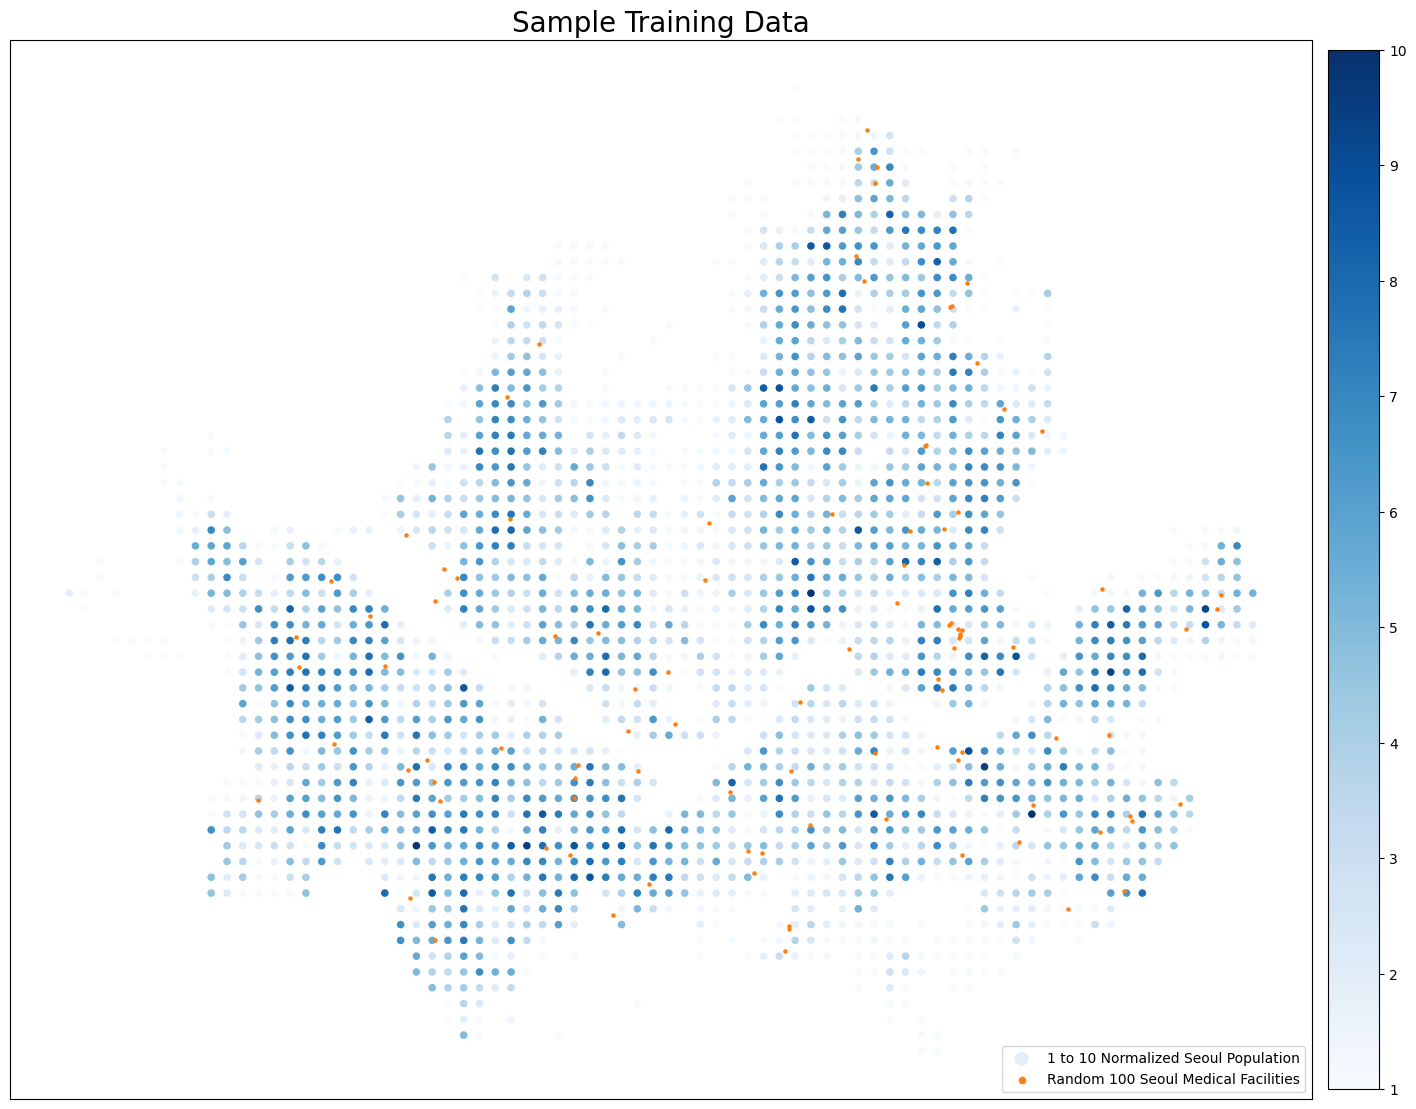

In [55]:
%%time

random_sample = random.choice(train_data)
users = random_sample['users']
facilities = random_sample['facilities']
demand = random_sample['demand']


fig, ax = plt.subplots(figsize=(20,18))

plt.scatter(users[:,0], users[:,1], c = demand.numpy(), cmap='Blues', s=20, label = '1 to 10 Normalized Seoul Population')
plt.colorbar(shrink=0.75 ,pad=0.01)
plt.scatter(facilities[:,0], facilities[:,1], c='C1', s=5, label = 'Random 100 Seoul Medical Facilities')

ax.axis('scaled')
ax.tick_params(axis='both', left=False, top=False, right=False,
               bottom=False, labelleft=False, labeltop=False,
               labelright=False, labelbottom=False)

ax.set_title("Sample Training Data", fontsize=20)
ax.legend(loc='lower right', markerscale = 2)

In [57]:
## Save the data
with open(path + "/sample/train_20_2000.pkl", "wb") as f:
    pickle.dump(train_data, f)
    
del train_data

with open(path +"/sample/train_20_2000.pkl", "rb") as f:
    train_data = pickle.load(f)

In [65]:
train_data[0]['users'].shape

torch.Size([2152, 2])

In [68]:
train_data[0]['facilities'].shape

torch.Size([100, 2])

# 6. make validation & test dataset

- number of validation dataset: 2000

- number of test dataset: 2000

In [59]:
%%time
val_data = gen_train_data_original(2000)
test_data = gen_train_data_original(2000)

with open(path + "/sample/val_20_2000.pkl", "wb") as f:
    pickle.dump(val_data, f)
    
with open(path + "/sample/test_20_2000.pkl", "wb") as f:
    pickle.dump(test_data, f)
    
del val_data, test_data

with open(path + "/sample/val_20_2000.pkl", "rb") as f:
    val_data = pickle.load(f)
with open(path + "/sample/test_20_2000.pkl", "rb") as f:
    test_data = pickle.load(f)
    
len(val_data)
len(test_data)

Wall time: 2.42 s


2000

Wall time: 23.5 ms


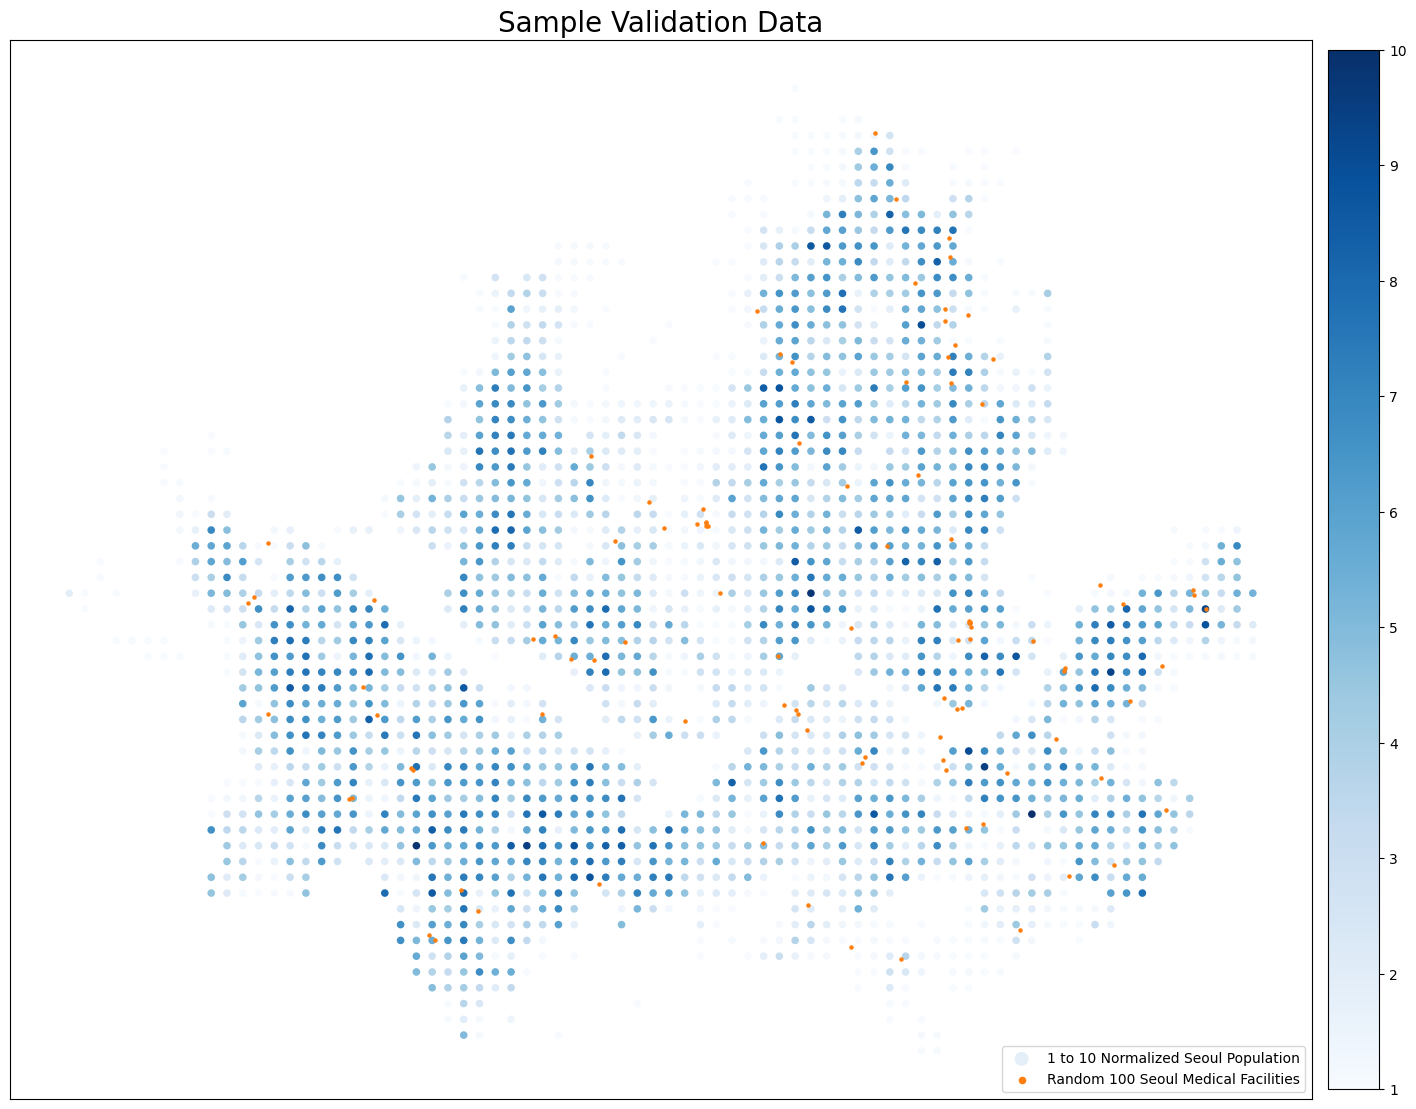

In [60]:
%%time

random_sample = random.choice(val_data)
users = random_sample['users']
facilities = random_sample['facilities']
demand = random_sample['demand']


fig, ax = plt.subplots(figsize=(20,18))

plt.scatter(users[:,0], users[:,1], c = demand.numpy(), cmap='Blues', s=20, label = '1 to 10 Normalized Seoul Population')
plt.colorbar(shrink=0.75 ,pad=0.01)
plt.scatter(facilities[:,0], facilities[:,1], c='C1', s=5, label = 'Random 100 Seoul Medical Facilities')

ax.axis('scaled')
ax.tick_params(axis='both', left=False, top=False, right=False,
               bottom=False, labelleft=False, labeltop=False,
               labelright=False, labelbottom=False)

ax.set_title("Sample Validation Data", fontsize=20)
ax.legend(loc='lower right', markerscale = 2)